### COMMON INSTRUCTIONS
Make sure to follow these instructions in order to ensure your submission is gradeable. If the automatic grading fails (check via Validate), no points are assigned!
1. Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
2. Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".
3. If you work in a group, please always work and submit in a shared server under the name of your group.
   If you work alone, then always work and submit on the server called "My Server".
4. Using Large Language Models and other AI tools is discouraged. Do not paste external code, as it can be tracked!
5. Do not upload notebooks. Always work in notebooks on the server.
6. Do not copy cells inside a notebook. Add a new cell and copy code from another cell if needed.

In [1]:
!tar czf myfiles.tar.gz ./*

---

# eXplainable AI, Assignment 5
# Ulm University - Institute of Artificial Intelligence
# Summer Term 2026 - Due: Wed, May 20, 2026, 2pm - Moodle
# Exercise 5 - Model-agnostic local feature importance explanation

In [1]:
!pip install torch torchvision

In [2]:
!pip install matplotlib

In [6]:
!pip install lime

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x8

In [7]:
from PIL import Image
import torch
import torchvision
from torchvision import transforms
import numpy as np
from matplotlib import pyplot as plt

In [8]:
## The model we will explain (trained on ImageNet)
from torchvision.models import convnext_tiny as model_builder, ConvNeXt_Tiny_Weights as WeightLibrary
## Some alternatives for playground (copy the cell content):
#from torchvision.models import alexnet as weight_builder, AlexNet_Weights as WeightLibrary
#from torchvision.models import resnet18 as model_builder, ResNet18_Weights as WeightLibrary
#from torchvision.models import resnet101 as model_builder, ResNet101_Weights as WeightLibrary
weights = WeightLibrary.DEFAULT
model = model_builder(weights=weights)
model.eval()


## We want to explain why the prediction for "Egyptian cat"
target_class = 285

transform = weights.transforms()
# convenience function: undo normalization of the cropped image for plotting
unnormalize = transforms.Compose([
    transforms.Normalize(mean=[0.,0.,0.], std=[1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.]),
])

## The example image
img: Image = Image.open("cat.jpg")
# Prepare it to serve as model input
img_t: torch.Tensor = transform(img)
# We need to put the one image in a single batch to be able to run it through the model.
batch_t = torch.unsqueeze(img_t, 0)
processed_img: np.ndarray = unnormalize(img_t).cpu().detach().numpy().transpose(1, 2, 0)

## Example evaluation of the model (initializes the computational graph)
batch_t.requires_grad = True
out = model(batch_t)
value, index = torch.max(out, 1)
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
print(f"Predicted class ID: {index.item()} (logit: {value.item():.2f}, confidence: {percentage[target_class].item():.2f}%)")
del percentage, out

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /home/student/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 70.8MB/s] 


Predicted class ID: 285 (logit: 7.85, confidence: 54.86%)


## 1 - Gradient-based explanations (4pts)

### Helpers: Gradient Calculation

To help with the calculation of gradients we use `pytorch` here (If your are more familiar with other automatic gradient calculation methods you can recreate this exercise in these frameworks - if you want). As seen in the lecture, gradients of a concatenation of differentiable functions can be calculated by conducting a forward and a backward pass through the computational graph. `pytorch` implements this by the `torch.Tensor` class: Vector values are stored within a tensor, and operations like summation and multiplication etc. link their output to their inputs, thus creating a computational graph. The backpropagation respectively registers the gradients to each tensor in the graph. Here is a short introduction of the relevant functions of `pytorch` used to do that (applicable to instances of `torch.Tensor`):

- `tensor.grad` contains the gradients for a given tensor (if they are calculated)
- `tensor.requires_grad` enables/disables (`Bool`) the collection of gradients for that tensor.
- `tensor.backward()` calculates all gradients in the computation graph. (usually called on a loss you want to minimize)
- `tensor.detach()` disconnects the tensor from the current computation graph. Afterwards no gradients can flow through.

More can be found at: https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html

### Helpers: Visualizing heatmaps
For visualizing heatmaps, their values need to be scaled into the plotting range $[-1, 1]$.

*Hints*:
- `matplotlib` offers the convenient option `cmap="hot"` (best for positive-only) or `cmap="bwr"` (e.g., for signed heatmaps) to plot heatmaps via `plt.imshow`. Note that this option automatically mean-shifts and scales the heatmap into the matplotlib plotting value range. To control this (in particular to not accidentally shift the zero), normalize the heatmap yourself and set the `vmin` and `vmax` values of `imshow` manually (e.g., $[-1,1]$).

In [10]:
def normalize_and_plot_heatmap(heatmap: torch.Tensor,  # dim HxW
                               processed_image: torch.Tensor,  # dim 3xHxW
                               title: str = "Heatmap",
                              ):
    """Plot a given heatmap side-by-side to its image using the matplotlib `bwr` heatmap."""
    # make sure the heatmap can be used by matplotlib
    # (i.e., is detached from the computational graph and on CPU)
    heatmap = heatmap.detach().cpu()
    
    fig, axes = plt.subplots(1, 2)
    axes[1].set_title(title)
    
    # Scale to fit all values in the range of [-1, 1]
    heatmap_normalized = heatmap / heatmap.abs().max()
    
    axes[0].imshow(processed_image)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_normalized, cmap='bwr', vmin=-1, vmax=1)
    #ax[1].imshow(saliency.abs(), cmap='hot', vmin=0, vmax=1)  # `hot` also is useful for a positive only presentation; here, vmin=0
    
    axes[1].axis('off')
    fig.tight_layout()
    
    return fig, axes

### 1.1 Vanilla Saliency (2pts)
Implement a method to explain an input image by calculating the gradient of each pixel (vanilla saliency). The result should be a heatmap (tensor) which holds for each pixel the maximum gradient value across its channels.

You can use the cat picture from above as an instance to explain and use the fixed class for "Egyptian cat".
Visualize the image, the vanilla saliency map (answering "Which feature was of *positive or negative* relevance"), and the absolute values of the vanilla saliency map (answering "Which feature was of *any* relevance").

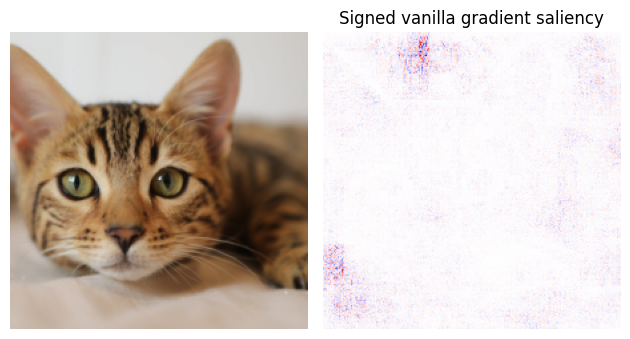

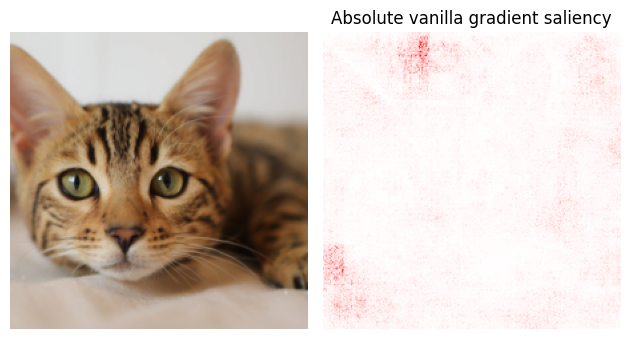

In [23]:
def collect_gradients(model: torch.nn.Module,
                      batch: torch.Tensor,  # dim batch x 3xHxW
                      target_class: int) -> torch.Tensor:
    """Evaluate model on batch of images (dim batchx3xHxW) and return a same-sized vector with the per value gradient."""
    saliency_raw_batch = None
    # YOUR SOLUTION HERE
    batch = batch.clone().detach().requires_grad_(True)
    _ = model.zero_grad(set_to_none=True) if hasattr(model, "zero_grad") else None
    saliency_raw_batch = (lambda output: (output[:, target_class].sum().backward(), batch.grad.detach().clone())[-1])(model(batch))

    
    return saliency_raw_batch  # dim batch x 3xHxW


# Your Solution
def vanilla_saliency(model: torch.nn.Module,
                     batch: torch.Tensor,  # dim batch x 3xHxW
                     target_class: int = target_class) -> torch.Tensor:
    """Evaluate model on batch of images (dim batch x 3xHxW) and return per pixel its maximum vanilla gradient saliency (dim batch x HxW)."""
    saliency_raw_batch: torch.Tensor = collect_gradients(model, batch, target_class)  # dim batch x 3xHxW
    saliency_batch = None
    
    # YOUR SOLUTION HERE
    abs_grad_sal = saliency_raw_batch.abs()
    max_channel_idx = abs_grad_sal.argmax(dim=1, keepdim=True)
    saliency_batch = saliency_raw_batch.gather(dim=1, index=max_channel_idx).squeeze(1)
    
    return saliency_batch  # dim = batch x HxW

saliency_batch = vanilla_saliency(model, batch_t, target_class)
saliency = saliency_batch[0]  # dim HxW

# Visualize
fig, _ = normalize_and_plot_heatmap(saliency, processed_img, "Signed vanilla gradient saliency")
fig.show()
fig, _ = normalize_and_plot_heatmap(saliency.abs(), processed_img, "Absolute vanilla gradient saliency")
fig.show()

In [26]:
assert tuple(saliency_batch.size()) == (1, 224, 224), f"Received a vanilla gradient saliency map of size {saliency_batch.size()} but expected [1, 224,224] (batch x H x W)"
# (some more hidden tests)
print('Success!')

Success!


### 1.3 Integrated Gradients Calculation (1.5 pts)

Implement the Integrated Gradients method (you may use `torch.trapezoid` for the integration and your `collect_gradients` method from above). For now, use as baseline the black image (all zeros), use 10 steps as a reasonable number, and explain the above model's feature relevance on the cat image.

*Hints*:
- `torch` offers the convenient method `torch.trapezoid` for integration of a discrete set of vectors. Make sure to set the stepsize `dx` correctly. Note: As compared to the Riemann sum integral approximation suggested in the original Integrated Gradients paper, this uses the slightly more accurate trapezoidal approximation.
- Like vanilla saliency, aggregate in the end by taking the maximum over each pixel's channels. Mind that this only should be done in the end!

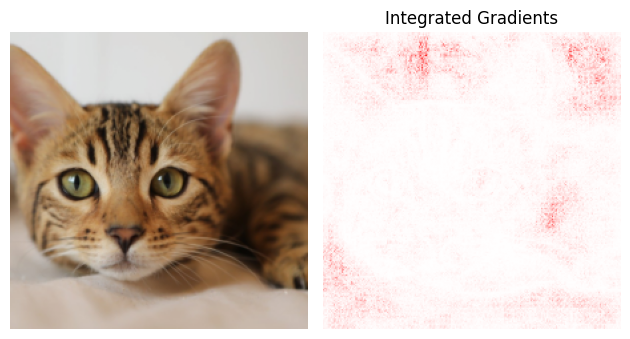

In [29]:
def integrated_gradients(model,
                         image: torch.Tensor, baseline: torch.Tensor,  # both dim 3xHxW
                         target_class: int = target_class, steps: int = 5) -> torch.Tensor:
    """Calculate Integrated Gradients heatmap for given model, input image, and target class."""
    ig = None
    # YOUR SOLUTION HERE

    img = image.unsqueeze(0)
    baseline = baseline.unsqueeze(0)

    alphas = torch.linspace(0,1, steps+1)
    interpolated = baseline + alphas.view(-1,1,1,1) * (img - baseline)
    grads = collect_gradients(model, interpolated, target_class)
    ig_channels = torch.trapezoid(grads, dx=1.0 / steps, dim=0)
    ig_channels = ig_channels * (img - baseline).squeeze(0)
    ig = ig_channels.abs().max(dim=0).values
    

    
    return ig  # dim HxW

# Set the baseline
baseline = torch.zeros_like(img_t)

ig = integrated_gradients(model, img_t, baseline, target_class)

# Visualize the image and the saliency map
_ = normalize_and_plot_heatmap(ig, processed_img, "Integrated Gradients")

In [30]:
# (hidden tests)
print('Success!')

Success!


### 1.4 Integrated Gradients: Choice of Baseline (0.5 + 0.5pts)
Now test out also other baselines (and step sizes) and suggest a different than the all-zero one from above.
What is an advantage and disadvantage of the all-zero baseline compared to your suggestion?

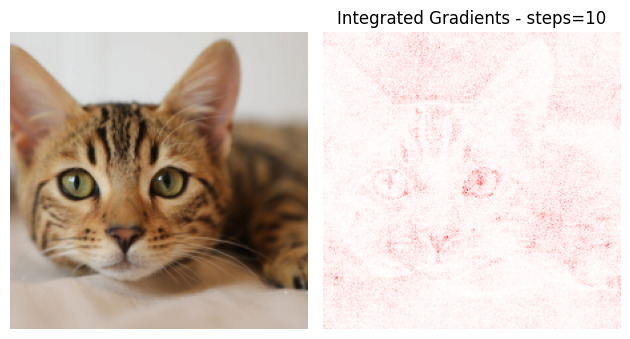

In [57]:
new_baseline = baseline  # set your new one here by replacing the dummy one
# YOUR SOLUTION HERE
#new_steps = 1  # set your custom amount of steps here (don't choose this >10 for the submission)
#ig = integrated_gradients(model, img_t, baseline=new_baseline, steps=new_steps, target_class=target_class)
#_ = normalize_and_plot_heatmap(ig, processed_img, f"Integrated Gradients - steps={new_steps}")

#new_steps = 2  # set your custom amount of steps here (don't choose this >10 for the submission)
#ig = integrated_gradients(model, img_t, baseline=new_baseline, steps=new_steps, target_class=target_class)
#_ = normalize_and_plot_heatmap(ig, processed_img, f"Integrated Gradients - steps={new_steps}")

#new_steps = 3  # set your custom amount of steps here (don't choose this >10 for the submission)
#ig = integrated_gradients(model, img_t, baseline=new_baseline, steps=new_steps, target_class=target_class)
#_ = normalize_and_plot_heatmap(ig, processed_img, f"Integrated Gradients - steps={new_steps}")

#new_steps = 5  # set your custom amount of steps here (don't choose this >10 for the submission)
#ig = integrated_gradients(model, img_t, baseline=new_baseline, steps=new_steps, target_class=target_class)
#_ = normalize_and_plot_heatmap(ig, processed_img, f"Integrated Gradients - steps={new_steps}")

# Baseline Gaussian noise with 0.1 std deviation
baseline_gaussian = torch.randn_like(img_t) * 0.1

new_baseline = baseline_gaussian
new_steps = 10  # set your custom amount of steps here (don't choose this >10 for the submission)
ig = integrated_gradients(model, img_t, baseline=new_baseline, steps=new_steps, target_class=target_class)
_ = normalize_and_plot_heatmap(ig, processed_img, f"Integrated Gradients - steps={new_steps}")

In [59]:
assert new_baseline.mean().item() != baseline.mean().item() or \
    new_baseline.max().item() != baseline.max().item() or \
    new_baseline.min().item() != baseline.min().item(), \
    "You are supposed to use a different baseline, but key statistics matched."

Advantage and disadvantage of all-zero baseline:<br>
YOUR ANSWER HERE<br>
Step size=10 - as big as possible (without going over 10)<br>benefit: more accurate trapezoidal approximation (apparently a rough default value in practice)<br>

Baseline of gaussian noise (std=0.1) around 0<br>
Advantage: random noise adds non-neutral structure (any image with classifiable feature information has non-uniform values)<br>
Disadvantage: random chance can introduce artifacts into the attribution.<br>

Baseline of all-zero pixel values:<br>
Advantage: simple & deterministic path from 0 to the image<br>
Disadvantage: all-black pixel images are not really in the ImageNet model training data, it was never trained on it, some pixels may appear more relevant when they should not & be less useful for this "egyptian cat" classification.<br>

## Activation-map based Feature Attribution — Grad‑CAM

### Helpers
To collect the activation map outputs, we use the `pytorch` hooking mechanism.
With that one can register functions of a specific signature to be called upon steps in the forward- or backpropagation.
We here need the forward propagation hooks.

Hooks can be registered using the `module.register_forward_hook` function (respectively the `register_backward_hook` for capturing gradients).
A hook created like that can be de-registered using `hook.remove()`.

In [60]:
# Activations and gradients get stored in these global variables.
_activations = None

def register_forward_hook(model: torch.nn.Module, target_module_name: str) -> torch.utils.hooks.RemovableHandle:
    """Registers hooks that will store activations of the forward pass to `activations`,
    and gradients of backward pass to `gradients`.
    Returns the handles for later deletion."""
    
    # To store the activations (without gradient), we use the pytorch hook mechanism.
    # (1) define the hook function:
    def save_activation(module, input, output):
        global _activations
        _activations = output.detach()
    
    # (2) register the hook
    target_module = dict(model.named_modules())[target_module_name]
    handle_a = target_module.register_forward_hook(save_activation)

    return handle_a

## Class Activation Mapping (2pt)
Implement the CAM method. Use `"bicubic"` interpolation to scale up the weighted sum of activations to input image size (you may use the pytorch function `torch.nn.functional.interpolate` for that).
Use CAM to explain the feature importance of the given model on above cat image.

*Hint*: For efficiency, first calculate the weighted sum on the low-resolution activation maps, then upscale them.

In [61]:
# Select the last convolutional layer for recording activations (after activation)
print(model)
last_conv_layer_name = 'features'  # the output of the complete features block
linear_weights_layer_name = 'classifier.2'  # we ignore the normalization layer inbetween, since this is just a uniform (i.e., non-activation map specific) shift and scaling

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
 

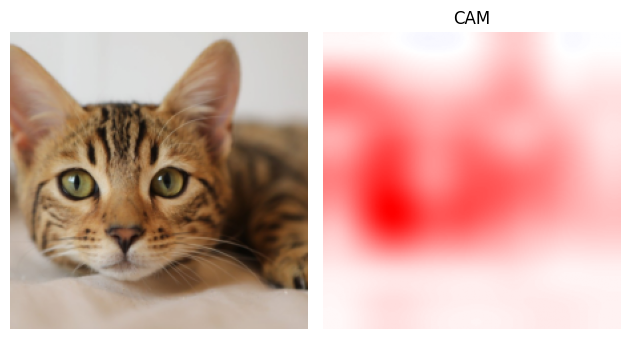

In [72]:
from torch.nn.functional import interpolate

def cam(model,
        batch, # dim batch x 3 x H x W
        target_class: int = target_class,
        last_conv_layer_name: str = last_conv_layer_name,
        linear_weights_layer_name: str = linear_weights_layer_name
       ) -> torch.Tensor:  # dim batch x HxW
    """Registers (and later deletes) a hook to collect activations. Returns CAM explanation.
    Details: First collects the weighted sum of activations, then upsamples using `bicubic` interpolation."""
    # register the hook
    global _activations
    handle_a = register_forward_hook(model, last_conv_layer_name)

    batch_size, in_channels, H, W = batch.size()

    heatmap = None
    
    # YOUR SOLUTION HERE
    handle_a = register_forward_hook(model, last_conv_layer_name)
    out = model(batch)
    act = _activations
    weights = dict(model.named_modules())[linear_weights_layer_name].weight[target_class]
    weighted = (act*weights.view(1,-1,1,1)).sum(dim=1,keepdim=True)
    heatmap=interpolate(weighted,size=(H,W),mode='bicubic',align_corners=False)
    # remove the hook again
    handle_a.remove()
    heatmap = heatmap.detach().reshape(batch.size()[0], batch.size()[-2], batch.size()[-1])  # dim: batch x H x W
    return heatmap

heatmaps = cam(model, batch_t, target_class=target_class,
               last_conv_layer_name=last_conv_layer_name, linear_weights_layer_name=linear_weights_layer_name)

# Visualize the image and the saliency map
_ = normalize_and_plot_heatmap(heatmaps.squeeze(0), processed_img, "CAM")

In [73]:
# (hidden tests)
print('Success!')

Success!


## CAM Applicability (1.5pt)

Consider (and possibly inspect) the following other model architectures (torchvision implementations of AlexNet, ResNet18, VGG16). To which of them is CAM applicable, to which not? Why?

In [81]:
from torchvision.models import alexnet as alt_model_builder, AlexNet_Weights as AltWeightLibrary
#from torchvision.models import resnet18 as alt_model_builder, ResNet18_Weights as AltWeightLibrary
#from torchvision.models import vgg16 as alt_model_builder, VGG16_Weights as AltWeightLibrary
alt_weights = AltWeightLibrary.DEFAULT
alt_model = alt_model_builder(weights=alt_weights)
alt_model.eval()
alt_model



AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

YOUR ANSWER HERE<br>
ResNet18 should work, layer4 output: 512x7x7 tensor, then avgpool outputs a 512x1x1 tensor (one scalar per feature channel) and then directly uses these 512 scalars as inputs to the fc layer for weighted classification -> 1:1 mapping of EACH of the 512 activation map channels -> exactly what CAM needs!<br>
VGG16 No, because the global avg pooling outputs a 512x7x7 tensor (not 512x1x1 like ResNet), this tensor is then flattened to its 25088 values into 1 vector and few through 3 linear layers in a row which mix spatial positions & channels -> we can no longer cleanly map 1:1 classifier weight to 1 activation map channel -> CAM not usable <br>
AlexNet No, similarly to VG616 the avgpool outputs a 256x6x6 tensor -> which si then flattened to 9216 values into 1 vector & fed through 3 linear layers mixing spatial positions & channels (dejavu) -> no longer cleanly mappable 1:1 clasifier weights to activation map channel -> CAM not usable <br>

## Grad-CAM (1pt)
Now extend above CAM implementation towards Grad-CAM, and explain the model's feature importance for the cat image.

In contrast to CAM, the relevance is estimated as the average gradient of the output with respect to the activation map's entries. Note that this allows to calculate Grad-CAM also for non-last convolutional layers; for comparability with CAM stick to the last convolutional layer for now.

*Hints*:
- Don't forget to zero the gradients before collecting new ones, using `model.zero_grad()`.
- The original Grad-CAM method suggests to clip the values to be all-positive. To compare, we here do a post-hoc clipping using ReLU (set all values <=0 to 0).

For the collection of gradients we can use the same hooking mechanism as for the collection of activations, just using `register_full_backward_hook` instead.

In [82]:
_gradients = None

def register_backward_hook(model: torch.nn.Module, target_module_name: str) -> torch.utils.hooks.RemovableHandle:
    """Registers hook that will store gradients of backward pass to `gradients`.
    Returns the handle for later deletion."""
    
    # (1) define the hook function:
    def save_gradient(module, grad_input, grad_output):
        global _gradients
        _gradients = grad_output[0].detach()
    
    # (2) register the hook
    target_module = dict(model.named_modules())[target_module_name]
    handle_g = target_module.register_full_backward_hook(save_gradient)

    return handle_g

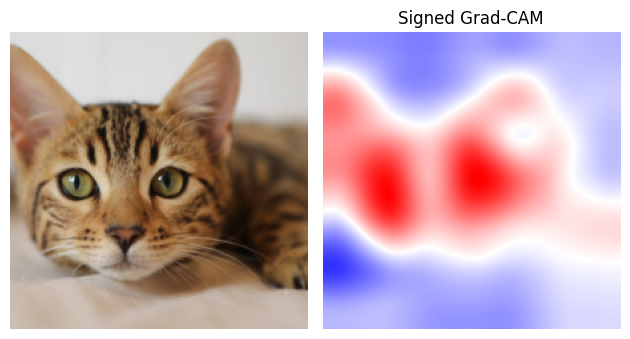

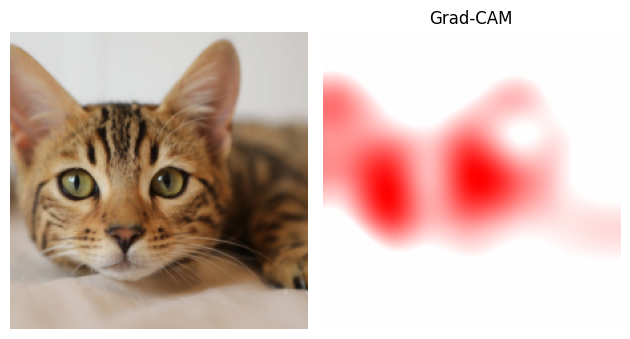

In [91]:
def grad_cam(model,
             batch, # dim batch x 3 x H x W
             target_class: int = target_class,
             conv_layer_name: str = last_conv_layer_name,
            ) -> torch.Tensor:  # dim: batch x H x W
    """Calculate (signed) Grad-CAM explanation."""
    # register the hook
    model.train().zero_grad()  # turn gradient selection on and start with zero gradients to not accumulate
    global _activations, _gradients
    _activations, _gradients = None, None
    handle_a = register_forward_hook(model, conv_layer_name)
    handle_g = register_backward_hook(model, conv_layer_name)

    batch_size, in_channels, H, W = batch.size()
    heatmap = None
    
    # YOUR SOLUTION HERE
    out = model(batch)
    score = out[:, target_class].sum()
    score.backward()
    weights = _gradients.mean(dim=(2,3), keepdim=True)
    weighted = (_activations * weights).sum(dim=1, keepdim=True)
    heatmap = torch.nn.functional.interpolate(weighted, size=(H,W), mode='bicubic', align_corners=False)
    # clean up the hooking
    handle_a.remove()
    handle_g.remove()
    _activations, _gradients = None, None

    # reshape into correct dimension
    heatmap = heatmap.detach().reshape(batch_size, H, W)  # dim: batch x H x W
    return heatmap

heatmaps = grad_cam(model, batch_t, target_class=target_class, conv_layer_name=last_conv_layer_name)
# Clipped to positive values
pos_heatmaps = torch.nn.functional.relu(heatmaps)

# Visualize the image and the saliency map
_ = normalize_and_plot_heatmap(heatmaps.squeeze(0), processed_img, "Signed Grad-CAM")
_ = normalize_and_plot_heatmap(pos_heatmaps.squeeze(0), processed_img, "Grad-CAM")

In [92]:
# (hidden tests)
print('Success!')

Success!


## Comparing Methods (2pt)

1. Which questions do the respective methods (CAM, Grad-CAM, vanilla saliency, Integrated Gradients) each answer?
2. Compare above explanations. Which of them look more plausible? What might be the issue of the other one(s)?

YOUR ANSWER HERE<br>
1. CAM: "Which spatial regions in the LAST feature-map most strongly activated the class-specific (label) neuron" or higher-level "Which feature locations lead to this classification the most?"<br>
Grad-CAM: Same basic questions as CAM - but a) applicable to any layer/architecture, and gradient-weighted activations<br>
vanilla saliencey: "How much did each pixel contribute to the score vs a chosen baseline value"<br>
Integrated Gradients: "Which pixels, if adjusted slightly, change the score the most?"<br>
2. <br>